# 1. importing the dataset from the UCI repository

In [863]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, header=None)

df.head()


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [864]:
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width", "height", "curb-weight",
           "engine-type", "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

df.columns = headers

path = "D:/IBM_DS/D_A/imports-85.data"
df.to_csv(path, index=False)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [865]:
df.dtypes

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

In [866]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [867]:
df.describe(include="all")

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.40,NaN,68,5500,NaN,NaN,?
freq,NaN,41,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


In [868]:
df["normalized-losses"].head(20)

0       ?
1       ?
2       ?
3     164
4     164
5       ?
6     158
7       ?
8     158
9       ?
10    192
11    192
12    188
13    188
14      ?
15      ?
16      ?
17      ?
18    121
19     98
Name: normalized-losses, dtype: str

In [869]:
df[["length", "compression-ratio", "horsepower"]]

,length,compression-ratio,horsepower
0,168.8,9.0,111
1,168.8,9.0,111
2,171.2,9.0,154
3,176.6,10.0,102
4,176.6,8.0,115
...,...,...,...
200,188.8,9.5,114
201,188.8,8.7,160
202,188.8,8.8,134
203,188.8,23.0,106


# 2. Data Wrangling: dealing with missing values, data format, data type conversion, renaming columns, etc.

---
## 2.1. dealing with missing values

In [870]:
# calculate the percentage of missing values in each column
missing_data = df.isnull()
print(missing_data.sum())


symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [871]:
# data doesn't have NaN values, but has "?" values, which are considered as missing values. So we need to replace "?" with NaN values.
df.replace("?", np.nan, inplace=True)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [872]:
# Shows the count of '?' for every column
print((df == "?").sum())

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [873]:
print(df.isnull().sum())

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [874]:
# droping duplicates, so the dataset will be more accurate and reliable. Duplicates can skew the results of the analysis and lead to incorrect conclusions.
df.drop_duplicates(inplace=True)
df.shape

(205, 26)

In [875]:
# see columns name and their data types
df.dtypes

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

* mean is almost close to median, so we can use mean to replace missing values.

In [876]:
# make up for numeric missing columns
missing_columns = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
for col in missing_columns:
    df[col] = df[col].astype(float)
    # inplace = true is an old way of doing it, which pandas team has deprecated.
    df[col] = df[col].fillna(df[col].mean())

In [877]:
# make up for categorical missing columns
common_doors = df['num-of-doors'].value_counts().idxmax()
df['num-of-doors'] = df['num-of-doors'].fillna(common_doors)

In [878]:
print("Total NaNs left in dataset:", df.isnull().sum().sum())
print("Total ? left in dataset:", (df == "?").sum().sum())

Total NaNs left in dataset: 0
Total ? left in dataset: 0


## 2.2. Data format

In [879]:
# data formating.. miles per gallon to kilometer per liter, pounds to kilogram, etc.
df["city-mpg"] = 235 / df["city-mpg"]
# rename the column name to be more clear
df.rename(columns={"city-mpg": "city-L/100km"}, inplace=True)


In [880]:
df["city-L/100km"].head()

0    11.190476
1    11.190476
2    12.368421
3     9.791667
4    13.055556
Name: city-L/100km, dtype: float64

## 2.3. Data type conversion

In [881]:
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-L/100km         float64
highway-mpg            int64
price                float64
dtype: object

In [882]:
# convert non-numeric data to numeric data, so that we can use it for analysis and modeling.
df[["bore", "stroke", "horsepower", "peak-rpm", "price"]] = df[["bore", "stroke", "horsepower", "peak-rpm", "price"]].astype(float)

In [883]:
# One-Hot Encoding
# concat dummies so to keep the original categorical columns
dummies = pd.get_dummies(
    df[["make", "fuel-type", "aspiration", "body-style", "drive-wheels", "engine-location", "engine-type", "fuel-system"]],
    drop_first=True,
    dtype=int
)
df = pd.concat([df, dummies], axis=1)

In [884]:
# convert number-of-doors via map method
mapping = {"two": 2, "four": 4}
df["num-of-doors"] = df["num-of-doors"].map(mapping)
# same for number-of-cylinders
mapping = {"two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "eight": 8, "twelve": 12}
df["num-of-cylinders"] = df["num-of-cylinders"].map(mapping)

In [885]:
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
                      ...   
fuel-system_idi        int64
fuel-system_mfi        int64
fuel-system_mpfi       int64
fuel-system_spdi       int64
fuel-system_spfi       int64
Length: 69, dtype: object

In [886]:
# price binning 
bins = np.linspace(min(df["price"]), max(df["price"]), 4)
groups = ["Low", "Medium", "High"]
df["price-binned"] = pd.cut(df["price"], bins, labels=groups, include_lowest=True)

<Axes: xlabel='price-binned', ylabel='Count'>

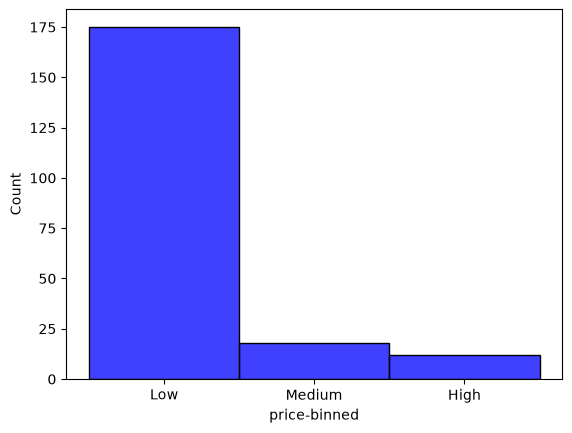

In [887]:
# building a histogram to visualize the price-binned column using seaborn
sns.histplot(df["price-binned"], kde=False, color="blue")


# Explotary Data Analysis (EDA) is an approach to analyze data sets to summarize their main characteristics, often with visual methods.

In [888]:
# analyze categorical variables using value_counts() method. This method is used to get a Series containing counts of unique values. The resulting object will be in descending order so that the first element is the most frequently-occurring element. Excludes NA values by default.
df["drive-wheels"].value_counts()

drive-wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

<Axes: xlabel='drive-wheels', ylabel='price'>

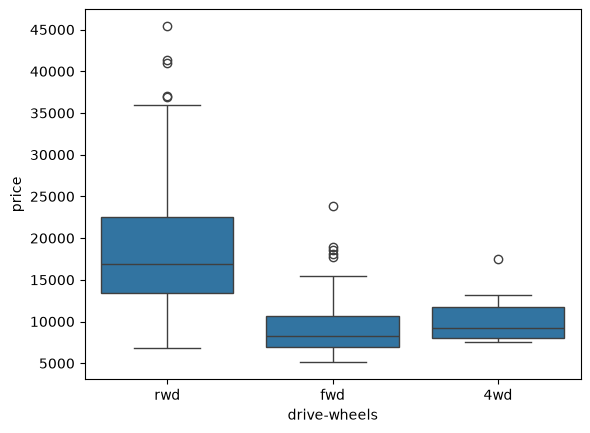

In [889]:
# boxplot to visualize the relationship between drive-wheels and price
sns.boxplot(x="drive-wheels", y="price", data=df)

<Axes: xlabel='engine-size', ylabel='price'>

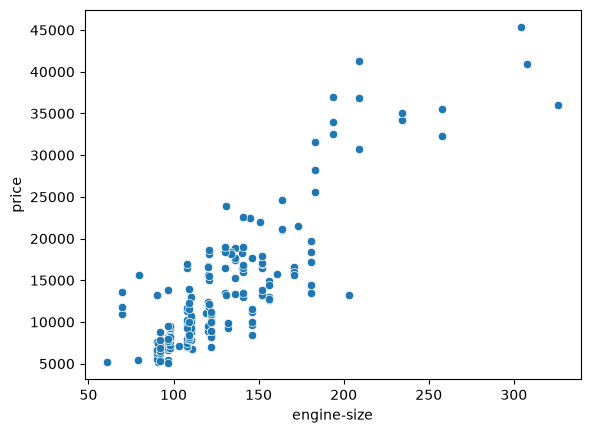

In [890]:
# scatter plot to visualize the relationship between engine-size and price
sns.scatterplot(x="engine-size", y="price", data=df)

In [891]:
''' grouping
    returns a groupby object that contains information about the groups, but does not contain the actual data.
    To access the data, we need to use an aggregation function such as mean(), sum(), count(), etc...
'''
df_test = df[["drive-wheels", "body-style", "price"]]
df_grp = df_test.groupby(["drive-wheels", "body-style"], as_index=False).mean()
df_grp

,drive-wheels,body-style,price
0,4wd,hatchback,10405.064677
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9930.934363
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [892]:
# pivot table to visualize the relationship between drive-wheels and body-style
df_pivot = df_grp.pivot(index="drive-wheels", columns="body-style", values="price")
df_pivot

body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,NaN,NaN,10405.064677,12647.333333,9095.750000
fwd,11595.0,8249.000000,8396.387755,9930.934363,9997.333333
rwd,23949.6,24202.714286,14278.269966,21711.833333,16994.222222


<Axes: xlabel='body-style', ylabel='drive-wheels'>

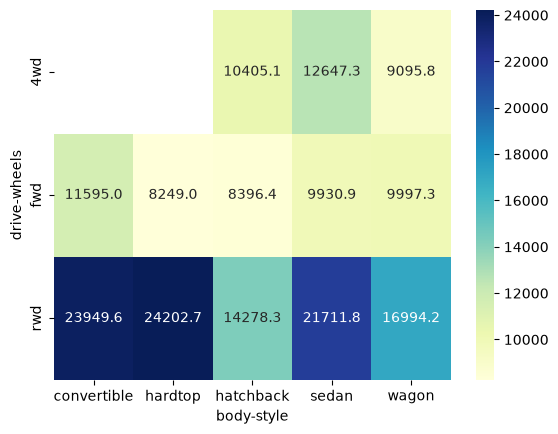

In [893]:
# heatmap to visualize the relationship between drive-wheels and body-style
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap="YlGnBu")

<Axes: xlabel='engine-size', ylabel='price'>

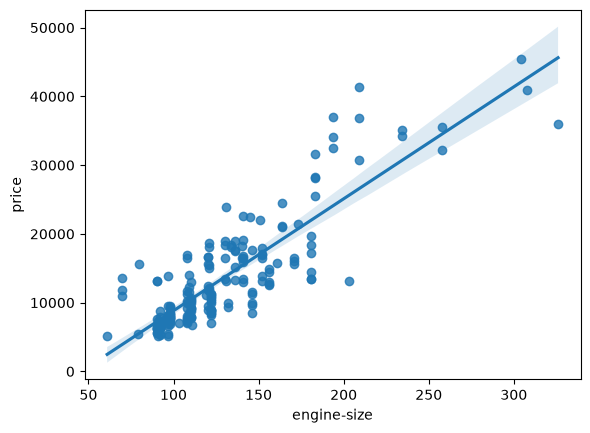

In [894]:
# correlation study and regplot
sns.regplot(x="engine-size", y="price", data=df)


In [895]:
# it's a highly positive correlation between engine-size and price, which means that as the engine size increases, the price also increases. The correlation coefficient is 0.87, which indicates a strong positive correlation.
# get correlation coefficient between engine-size and price
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.861752
price,0.861752,1.000000


<Axes: xlabel='peak-rpm', ylabel='price'>

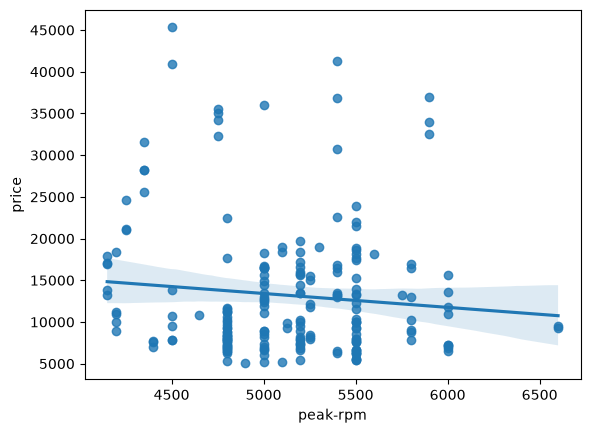

In [896]:
''' weak correlation between peak-rpm and price, which means that as the peak-rpm increases, the price does not change significantly.
    The correlation coefficient is -0.101616, which indicates a weak negative correlation.
'''

sns.regplot(x="peak-rpm", y="price", data=df)

In [897]:
# pearson correlation coefficient is a measure of the linear correlation between two variables. It ranges from -1 to 1, where 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation. The pearson correlation coefficient can be calculated using the corr() method in pandas.
pearson_coef, p_value = stats.pearsonr(df["engine-size"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is 0.8617522436859723  with a P-value of P = 9.669661923633061e-62


In [898]:
''' 
    chi square test is a statistical test used to determine if there is a significant association between two categorical variables.
    It compares the observed frequencies of the variables to the expected frequencies if there were no association between them.
    The test produces a chi-square statistic and a p-value, which can be used to determine if the association is statistically significant.
    we just care about p.. the more less p the stronger the relation is. 
'''
contingency_table = pd.crosstab(df["drive-wheels"], df["body-style"])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("The Chi-Square Statistic is", chi2, " with a P-value of P =", p)

The Chi-Square Statistic is 26.590363539055975  with a P-value of P = 0.0008317943771481913


In [899]:
# create df_ml for machine learning, which contains only the numerical columns that we will use for modeling.
df_ml = df.select_dtypes(include=['number'])
print(df_ml.dtypes.to_string())

symboling                 int64
normalized-losses       float64
num-of-doors              int64
wheel-base              float64
length                  float64
width                   float64
height                  float64
curb-weight               int64
num-of-cylinders          int64
engine-size               int64
bore                    float64
stroke                  float64
compression-ratio       float64
horsepower              float64
peak-rpm                float64
city-L/100km            float64
highway-mpg               int64
price                   float64
make_audi                 int64
make_bmw                  int64
make_chevrolet            int64
make_dodge                int64
make_honda                int64
make_isuzu                int64
make_jaguar               int64
make_mazda                int64
make_mercedes-benz        int64
make_mercury              int64
make_mitsubishi           int64
make_nissan               int64
make_peugot               int64
make_ply

In [900]:
# 1. Get absolute correlation values with the target variable
corr_with_price = df_ml.corr()['price'].abs()

# 2. Define your threshold (e.g., drop anything with less than 0.10 correlation)
threshold = 0.10
weak_features = corr_with_price[corr_with_price < threshold].index

# 3. Drop those weak features
df_ml = df_ml.drop(columns=weak_features)

print(f"Dropped {len(weak_features)} weak features: {list(weak_features)}")

Dropped 21 weak features: ['symboling', 'num-of-doors', 'stroke', 'compression-ratio', 'make_audi', 'make_isuzu', 'make_mazda', 'make_mercury', 'make_peugot', 'make_renault', 'make_saab', 'make_volkswagen', 'body-style_wagon', 'engine-type_dohcv', 'engine-type_l', 'engine-type_ohcf', 'engine-type_rotor', 'fuel-system_4bbl', 'fuel-system_mfi', 'fuel-system_spdi', 'fuel-system_spfi']


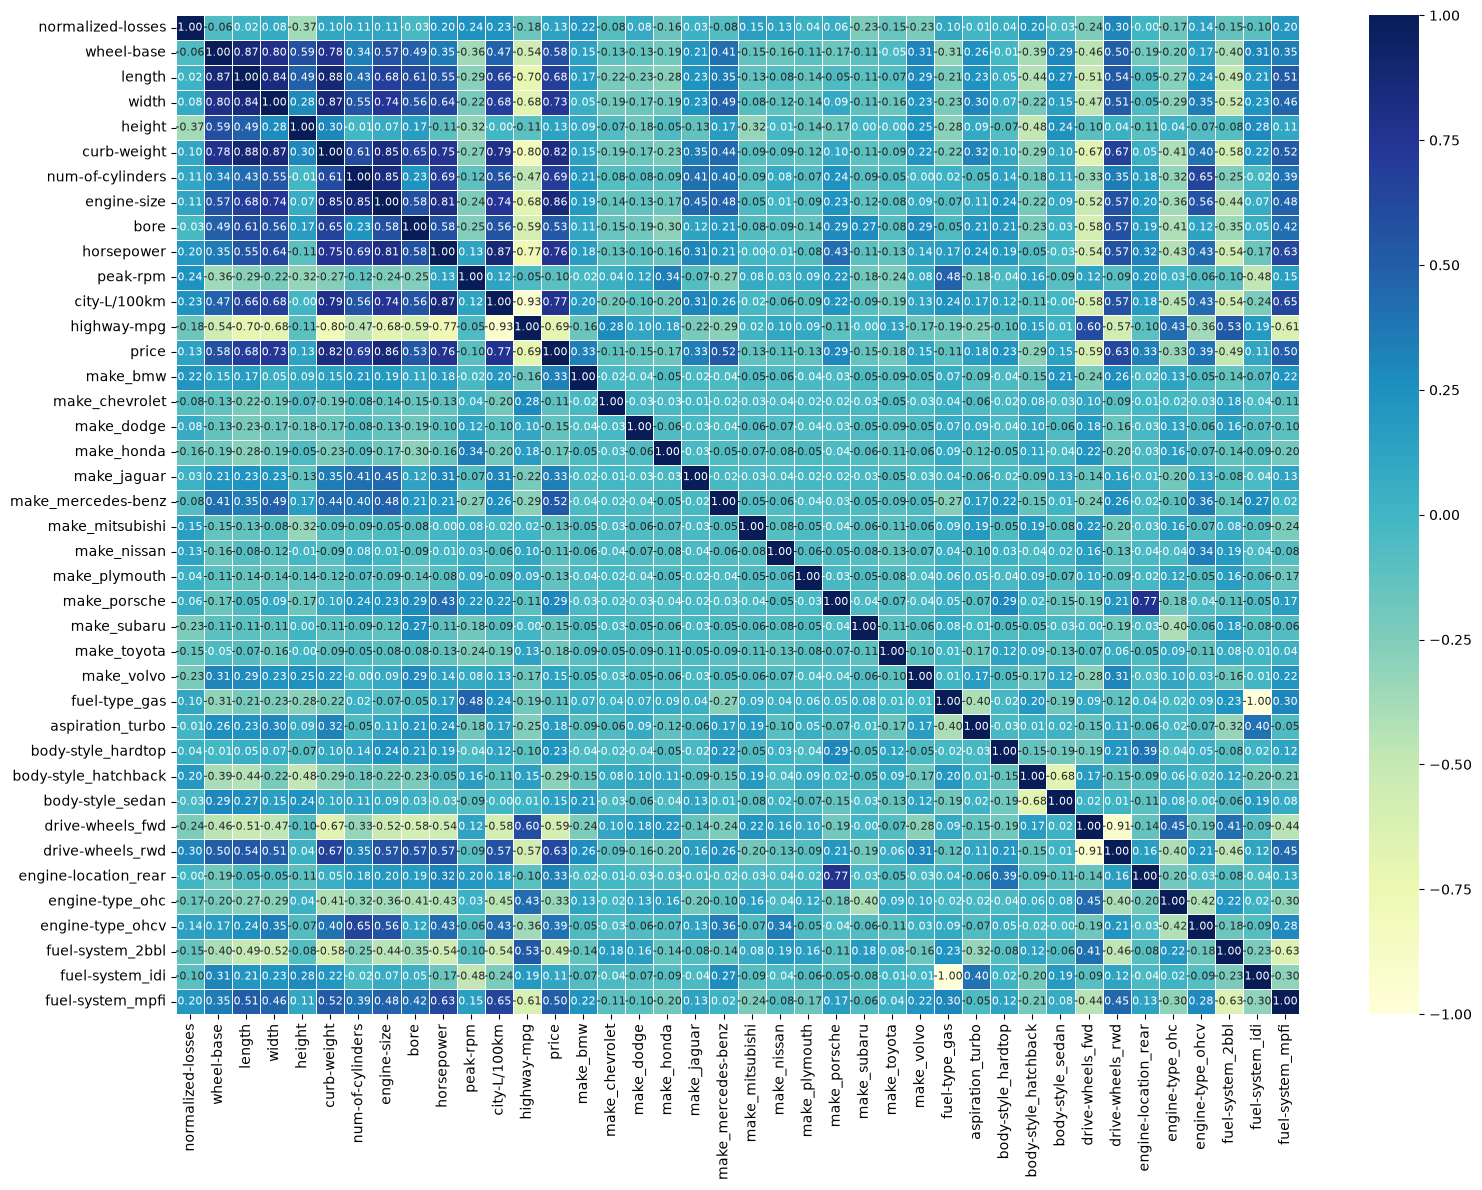

In [901]:
# heatmap to indicate correlation between all numerical variables in the dataset.


# 1. Expand the canvas size BEFORE plotting
plt.figure(figsize=(16, 12))

# 2. Draw heatmap with adjusted font size and formatting
sns.heatmap(
    df_ml.corr(numeric_only=True), 
    annot=True, 
    fmt=".2f",             # Force strictly 2 decimal places
    cmap="YlGnBu",         # Color palette
    linewidths=0.5,        # Adds clean gridlines between cells
    annot_kws={"size": 8}  # Shrinks text size to prevent overlapping
)

plt.tight_layout()
plt.show()

# Model Development is the process of creating a predictive model using machine learning algorithms.

In [902]:

# 1. Separate predictors (X) and target (y)
X = df_ml.drop('price', axis=1)
y = df_ml['price']

# 2. Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict and evaluate performance
y_pred = model.predict(X_test)

print("R² Score (Accuracy):", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))

R² Score (Accuracy): 0.8902783617784653
Mean Squared Error (MSE): 8555223.879473094


In [903]:
# cross-validation to evaluate the model's performance more robustly. This method splits the dataset into multiple folds, trains the model on some folds, and tests it on the remaining fold. It repeats this process multiple times and averages the results to provide a more reliable estimate of model performance.
from sklearn.model_selection import cross_val_score, KFold

#  shuffle rows first
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R² Scores:", cv_scores)

Cross-Validation R² Scores: [0.5776823  0.74126939 0.08792766 0.38793558 0.64210771]


- Dataset size is small, that's why we get inconsistent results... but just for practice techniques, we will continue with this dataset.

In [904]:
# regression coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients.sort_values(by='Coefficient', ascending=False, inplace=True)
print(coefficients)

                       Coefficient
engine-location_rear  16187.821956
make_mercedes-benz     9544.601095
make_bmw               7739.159334
aspiration_turbo       2844.036742
make_volvo             2384.075764
fuel-system_2bbl       2110.650987
make_subaru            1756.123199
fuel-system_mpfi       1503.788401
city-L/100km           1364.269756
fuel-system_idi         948.051740
make_porsche            683.240304
make_jaguar             590.041521
engine-type_ohc         546.480982
width                   350.488602
drive-wheels_rwd        289.643784
highway-mpg             228.690136
drive-wheels_fwd        217.075943
engine-size             140.389693
wheel-base               84.996115
curb-weight               3.752409
peak-rpm                  2.409272
normalized-losses        -0.590150
horsepower              -41.937717
body-style_sedan        -52.752767
length                  -74.269829
height                 -284.622853
make_toyota            -426.491475
engine-type_ohcv    

<Axes: xlabel='price'>

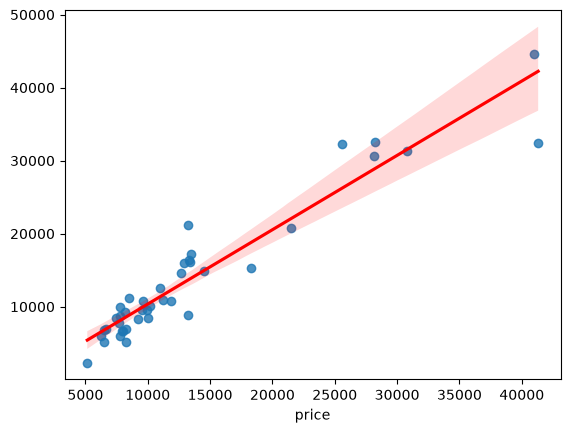

In [905]:
# regplot for evaluating the relationship between actual and predicted prices using seaborn
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})

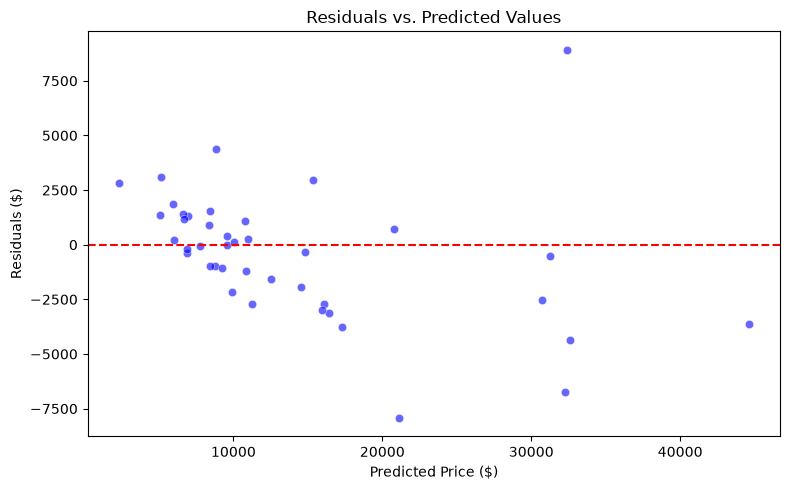

In [906]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color="blue")

# Add horizontal reference line at zero error
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.tight_layout()
plt.show()

In [907]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest captures non-linear pricing curves naturally
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest R²: 0.9340320730372609


In [908]:
# xgboost model for comparison
import xgboost as xg
xgb_model = xg.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost R²:", r2_score(y_test, y_pred_xgb))

XGBoost R²: 0.9190818631027432


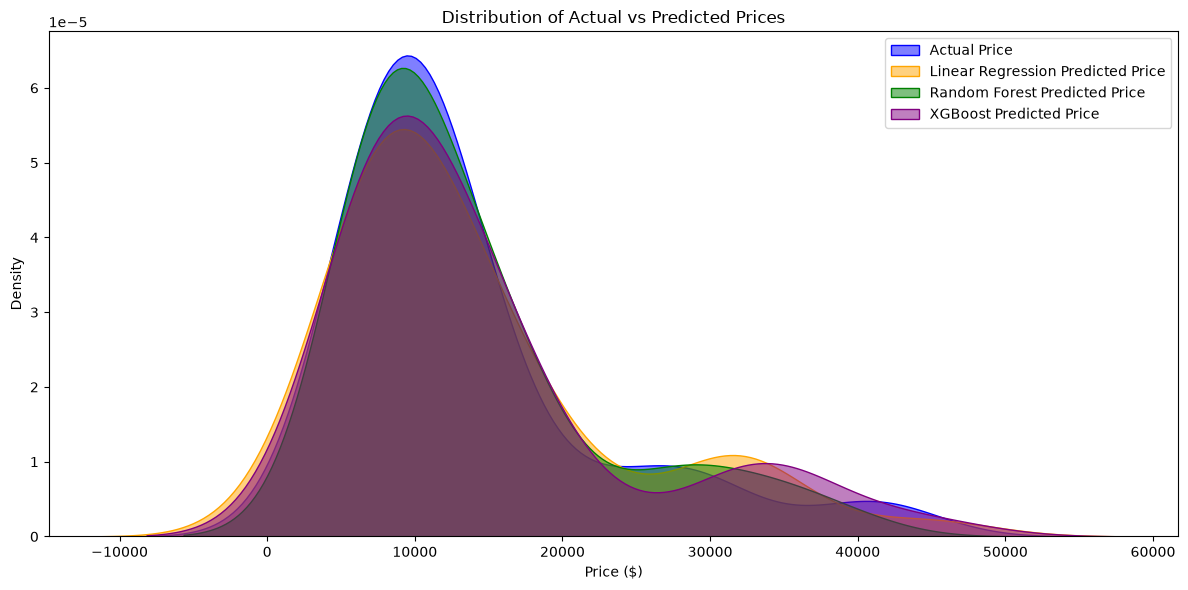

In [909]:
# distribution plot with seaborn to visualize the distribution of actual vs predicted prices for all three models
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test, label='Actual Price', color='blue', fill=True, alpha=0.5)
sns.kdeplot(y_pred, label='Linear Regression Predicted Price', color='orange', fill=True, alpha=0.5)
sns.kdeplot(y_pred_rf, label='Random Forest Predicted Price', color='green', fill=True, alpha=0.5)
sns.kdeplot(y_pred_xgb, label='XGBoost Predicted Price', color='purple', fill=True, alpha=0.5)
plt.title("Distribution of Actual vs Predicted Prices")
plt.xlabel("Price ($)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [910]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Unseen batch dataset
unseen_samples = [
    {"symboling": 1, "normalized-losses": 87, "wheel-base": 95.7, "length": 158.7, "width": 63.6, "height": 54.5,
     "curb-weight": 1982, "engine-size": 92, "bore": 3.05, "stroke": 3.03, "compression-ratio": 9.0, "horsepower": 62,
     "peak-rpm": 4800, "city-L/100km": 6.7, "highway-mpg": 35, "num-of-doors": 2, "num-of-cylinders": 4, "make_toyota": 1,
     "fuel-type_gas": 1, "body-style_hatchback": 1, "drive-wheels_fwd": 1, "engine-type_ohc": 1, "fuel-system_2bbl": 1},
    
    {"symboling": 0, "normalized-losses": 110, "wheel-base": 96.5, "length": 169.1, "width": 66.0, "height": 51.0,
     "curb-weight": 2290, "engine-size": 110, "bore": 3.15, "stroke": 3.58, "compression-ratio": 9.0, "horsepower": 86,
     "peak-rpm": 5800, "city-L/100km": 8.7, "highway-mpg": 33, "num-of-doors": 4, "num-of-cylinders": 4, "make_honda": 1,
     "fuel-type_gas": 1, "body-style_sedan": 1, "drive-wheels_fwd": 1, "engine-type_ohc": 1, "fuel-system_1bbl": 1},
    
    {"symboling": 0, "normalized-losses": 192, "wheel-base": 101.2, "length": 176.8, "width": 64.8, "height": 54.3,
     "curb-weight": 2395, "engine-size": 108, "bore": 3.50, "stroke": 2.80, "compression-ratio": 8.8, "horsepower": 101,
     "peak-rpm": 5800, "city-L/100km": 10.2, "highway-mpg": 29, "num-of-doors": 4, "num-of-cylinders": 4, "make_bmw": 1,
     "fuel-type_gas": 1, "body-style_sedan": 1, "drive-wheels_rwd": 1, "engine-type_ohc": 1, "fuel-system_mpfi": 1}
]

y_true = [6488, 10295, 21105]

# 2. Align columns and replace NaN values with 0
df_batch = pd.DataFrame(unseen_samples)
df_batch_aligned = df_batch.reindex(columns=X_train.columns, fill_value=0).fillna(0)

# 3. Predict across all models
preds_lr = model.predict(df_batch_aligned)
preds_rf = rf_model.predict(df_batch_aligned)
preds_xgb = xgb_model.predict(df_batch_aligned)

# 4. Display comparison table
comparison_df = pd.DataFrame({
    'Actual Price': y_true,
    'Linear Reg': np.round(preds_lr, 2),
    'Random Forest': np.round(preds_rf, 2),
    'XGBoost': np.round(preds_xgb, 2)
})

print("=== SAMPLE PREDICTIONS ===")
print(comparison_df.to_string(index=False))

# 5. Evaluate aggregate performance
print("\n=== AGGREGATE ERROR (Mean Absolute Error) ===")
print(f"Linear Regression MAE: ${mean_absolute_error(y_true, preds_lr):.2f}")
print(f"Random Forest MAE:     ${mean_absolute_error(y_true, preds_rf):.2f}")
print(f"XGBoost MAE:           ${mean_absolute_error(y_true, preds_xgb):.2f}")

=== SAMPLE PREDICTIONS ===
 Actual Price  Linear Reg  Random Forest      XGBoost
         6488     4846.83        5870.25  5362.830078
        10295    10827.98        9245.97  9358.679688
        21105    18337.84       15942.37 16696.800781

=== AGGREGATE ERROR (Mean Absolute Error) ===
Linear Regression MAE: $1647.10
Random Forest MAE:     $2276.47
XGBoost MAE:           $2156.56


In [912]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler, 
    StandardScaler, 
    RobustScaler, 
    Normalizer, 
    MaxAbsScaler
)
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# 1. Train/Test Split (Replace X and y with your variables)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pipeline setup with a scaling placeholder
pipe = Pipeline([
    ('scaler', MinMaxScaler()), 
    ('model', Ridge())
])

# 3. Grid Search over Normalization/Scaling techniques and Alpha values
param_grid = {
    'scaler': [
        MinMaxScaler(),      # Min-Max Normalization (scales features to [0, 1])
        Normalizer(),        # Vector Normalization (scales each sample row to unit norm)
        StandardScaler(),    # Z-score Standardization (mean=0, variance=1)
        RobustScaler(),      # Robust Normalization (uses median and IQR for outliers)
        MaxAbsScaler(),      # Scales features by max absolute value to [-1, 1]
        'passthrough'        # No normalization (raw data)
    ],
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# 4. Run Grid Search (Optimizing for R²)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

grid.fit(X_train, y_train)

# 5. Print Winning Config & Test Set R²
print("=== BEST SETUP ===")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best Validation R² (CV): {grid.best_score_:.4f}")

test_preds = grid.predict(X_test)
print(f"Final Test Set R²:        {r2_score(y_test, test_preds):.4f}")

# 6. View R² Scores across all Normalization combinations
results = pd.DataFrame(grid.cv_results_)
summary = results[[
    'param_scaler', 
    'param_model__alpha', 
    'mean_train_score', 
    'mean_test_score'
]].rename(columns={
    'param_scaler': 'Normalization Method',
    'param_model__alpha': 'Alpha',
    'mean_train_score': 'Train R²',
    'mean_test_score': 'Val R² (CV)'
})

# Clean up scaler names for printing
summary['Normalization Method'] = summary['Normalization Method'].astype(str).str.split('(').str[0]

print("\n=== R² COMPARISON TABLE ===")
print(summary.sort_values(by='Val R² (CV)', ascending=False).to_string(index=False))

=== BEST SETUP ===
Best Parameters: {'model__alpha': 0.1, 'scaler': 'passthrough'}
Best Validation R² (CV): 0.8382
Final Test Set R²:        0.8931

=== R² COMPARISON TABLE ===
Normalization Method   Alpha  Train R²  Val R² (CV)
         passthrough    0.10  0.959581     0.838170
        RobustScaler    0.10  0.959630     0.837843
      StandardScaler   10.00  0.945999     0.837705
      StandardScaler  100.00  0.894298     0.836543
        MaxAbsScaler    0.10  0.947918     0.833613
        MaxAbsScaler    1.00  0.914231     0.832124
        MinMaxScaler    1.00  0.924708     0.829398
        RobustScaler    1.00  0.943530     0.828319
        MaxAbsScaler    0.01  0.959098     0.828303
        MinMaxScaler    0.10  0.954935     0.827617
      StandardScaler    1.00  0.959045     0.823538
         passthrough    0.01  0.960440     0.821542
        RobustScaler    0.01  0.960441     0.821438
         passthrough    1.00  0.944386     0.819845
        MinMaxScaler    0.01  0.960204     

In [ ]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the co

: 

### NO SCALING IS BETTER, SMALL DATASET, NO NEED TO SCALE, AND SCALING IS NOT IMPROVING RESULTS. WE CANNOT EVEN SUFFER FROM OVERFITTING, BECAUSE DATASET IS TOO SMALL. SO, WE WILL NOT SCALE.